# MTI UNPAM Academic Assistant

Notebook ini berisi implementasi awal chatbot informasi akademik Program Magister Teknik Informatika UNPAM berbasis Text Mining, TF-IDF, dan Cosine Similarity.

## 1. Business Understanding

Tujuan project adalah membuat prototype chatbot yang membantu calon mahasiswa memahami struktur kurikulum, mata kuliah, peminatan, tesis, dan prospek karier MTI UNPAM.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from utils.chatbot_utils import load_faq_data, build_tfidf_engine, get_chatbot_response, evaluate_questions

DATA_PATH = PROJECT_ROOT / 'data' / 'faq_mti_unpam.csv'
EVAL_PATH = PROJECT_ROOT / 'data' / 'evaluation_questions.csv'

print('Project root:', PROJECT_ROOT)
print('Dataset path:', DATA_PATH)

Project root: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\TUGAS-21\mti-unpam-academic-chatbot
Dataset path: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA-MINING\TUGAS\TUGAS-21\mti-unpam-academic-chatbot\data\faq_mti_unpam.csv


## 2. Data Understanding

In [2]:
faq_df = load_faq_data(DATA_PATH)
faq_df.head()

,question,answer,category,semester,peminatan,source_type
0,Apa itu Program Magister Teknik Informatika UN...,Program Magister Teknik Informatika UNPAM adal...,profil_program,,,manual
1,Apa tujuan chatbot MTI UNPAM Academic Assistant?,Chatbot ini dibuat sebagai media bantu informa...,profil_program,,,manual
2,Apa saja mata kuliah Semester 1 MTI UNPAM?,Mata kuliah Semester I terdiri dari Algoritma ...,kurikulum_semester_1,1.0,,user_provided
3,Apa yang dipelajari pada Algoritma Analisis?,Algoritma Analisis membahas konsep perancangan...,kurikulum_semester_1,1.0,,manual
4,Apa yang dipelajari pada Data Mining?,"Data Mining membahas proses menemukan pola, hu...",kurikulum_semester_1,1.0,,manual


In [3]:
print('Jumlah FAQ:', len(faq_df))
print('Jumlah kategori:', faq_df['category'].nunique())
faq_df.info()

Jumlah FAQ: 34
Jumlah kategori: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   question     34 non-null     object
 1   answer       34 non-null     object
 2   category     34 non-null     object
 3   semester     34 non-null     object
 4   peminatan    34 non-null     object
 5   source_type  34 non-null     object
dtypes: object(6)
memory usage: 1.7+ KB


## 3. Visualisasi Distribusi Dataset

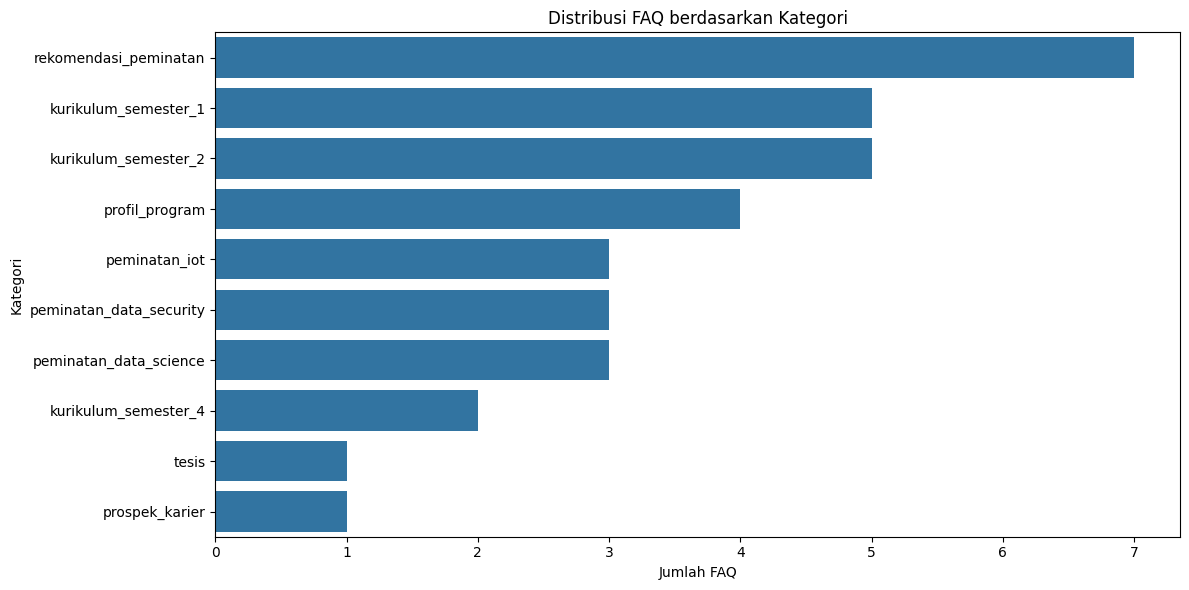

In [4]:
plt.figure(figsize=(12, 6))
sns.countplot(data=faq_df, y='category', order=faq_df['category'].value_counts().index)
plt.title('Distribusi FAQ berdasarkan Kategori')
plt.xlabel('Jumlah FAQ')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()

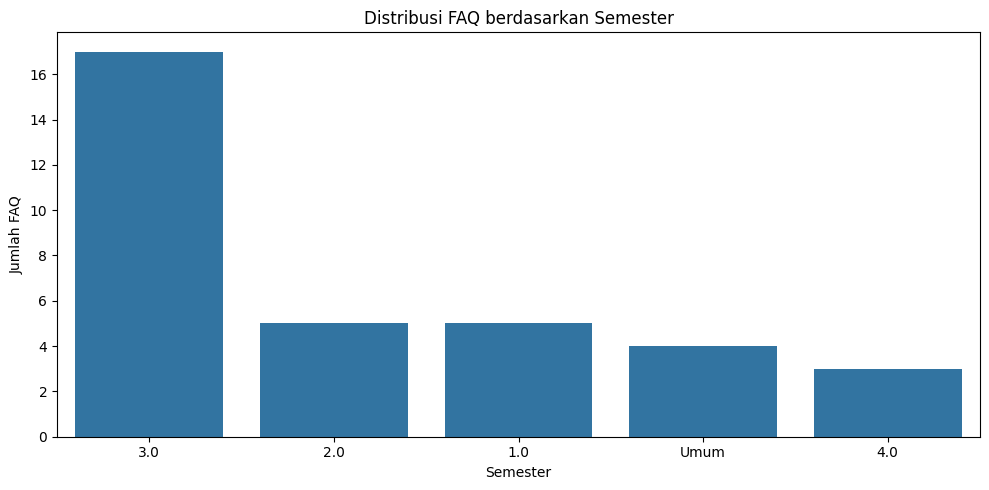

In [5]:
semester_df = faq_df.copy()
semester_df['semester'] = semester_df['semester'].replace('', 'Umum')
plt.figure(figsize=(10, 5))
sns.countplot(data=semester_df, x='semester', order=semester_df['semester'].value_counts().index)
plt.title('Distribusi FAQ berdasarkan Semester')
plt.xlabel('Semester')
plt.ylabel('Jumlah FAQ')
plt.tight_layout()
plt.show()

## 4. Modeling: TF-IDF dan Cosine Similarity

In [6]:
vectorizer, tfidf_matrix = build_tfidf_engine(faq_df)
print('TF-IDF matrix shape:', tfidf_matrix.shape)

TF-IDF matrix shape: (34, 208)


## 5. Pengujian Chatbot

In [7]:
sample_questions = [
    'Apa saja mata kuliah semester 1?',
    'Saya tertarik cyber security cocok peminatan apa?',
    'Peminatan Data Science belajar apa?',
    'Apa resep membuat nasi goreng?'
]

for q in sample_questions:
    result = get_chatbot_response(q, faq_df, vectorizer, tfidf_matrix, threshold=0.25)
    print('='*90)
    print('Pertanyaan:', q)
    print('Kategori:', result['category'])
    print('Similarity:', result['similarity_score'])
    print('Jawaban:', result['answer'])

Pertanyaan: Apa saja mata kuliah semester 1?
Kategori: kurikulum_semester_1
Similarity: 0.8512
Jawaban: Mata kuliah Semester I terdiri dari Algoritma Analisis, Data Mining, Modelling and Optimization, serta Sistem Komputer dan Jaringan.
Pertanyaan: Saya tertarik cyber security cocok peminatan apa?
Kategori: rekomendasi_peminatan
Similarity: 0.5277
Jawaban: Jika Anda tertarik pada keamanan siber, investigasi insiden, keamanan sistem, dan analisis bukti digital, maka peminatan Data Security dan Digital Forensik merupakan pilihan yang relevan.
Pertanyaan: Peminatan Data Science belajar apa?
Kategori: peminatan_data_science
Similarity: 0.7014
Jawaban: Peminatan Data Science berfokus pada analisis data, machine learning, natural language processing, computer vision, big data, dan visualisasi data untuk mendukung pengambilan keputusan berbasis data.
Pertanyaan: Apa resep membuat nasi goreng?
Kategori: fallback
Similarity: 0.1421
Jawaban: Maaf, saya belum memiliki informasi yang cukup untuk m

## 6. Evaluasi Sederhana

In [8]:
eval_df = pd.read_csv(EVAL_PATH)
eval_result = evaluate_questions(eval_df, faq_df, vectorizer, tfidf_matrix, threshold=0.25)
eval_result

,test_question,expected_category,predicted_category,similarity_score,status,is_correct,matched_question
0,Mata kuliah semester satu apa saja?,kurikulum_semester_1,kurikulum_semester_1,0.6447,answered,True,Apa saja mata kuliah Semester 1 MTI UNPAM?
1,Kalau saya suka cyber security cocoknya pemina...,rekomendasi_peminatan,rekomendasi_peminatan,0.3261,answered,True,"Saya tertarik keamanan siber, cocok ambil pemi..."
2,Peminatan data science belajar apa?,peminatan_data_science,peminatan_data_science,0.7014,answered,True,Apa fokus peminatan Data Science?
3,Apa perbedaan IoT dan data science?,rekomendasi_peminatan,rekomendasi_peminatan,0.7071,answered,True,Apa perbedaan peminatan Data Security dan Data...
4,Semester empat ada mata kuliah apa?,kurikulum_semester_4,kurikulum_semester_4,0.5183,answered,True,Apa mata kuliah Semester 4 MTI UNPAM?
5,"Saya suka memasak nasi goreng, apa resepnya?",fallback,rekomendasi_peminatan,0.2559,answered,False,"Saya tertarik keamanan siber, cocok ambil pemi..."
6,Berapa harga biaya kuliah terbaru?,fallback,peminatan_iot,0.3040,answered,False,Apa saja mata kuliah peminatan IoT?


In [9]:
accuracy = eval_result['is_correct'].mean()
print(f'Akurasi evaluasi sederhana: {accuracy:.2%}')

Akurasi evaluasi sederhana: 71.43%


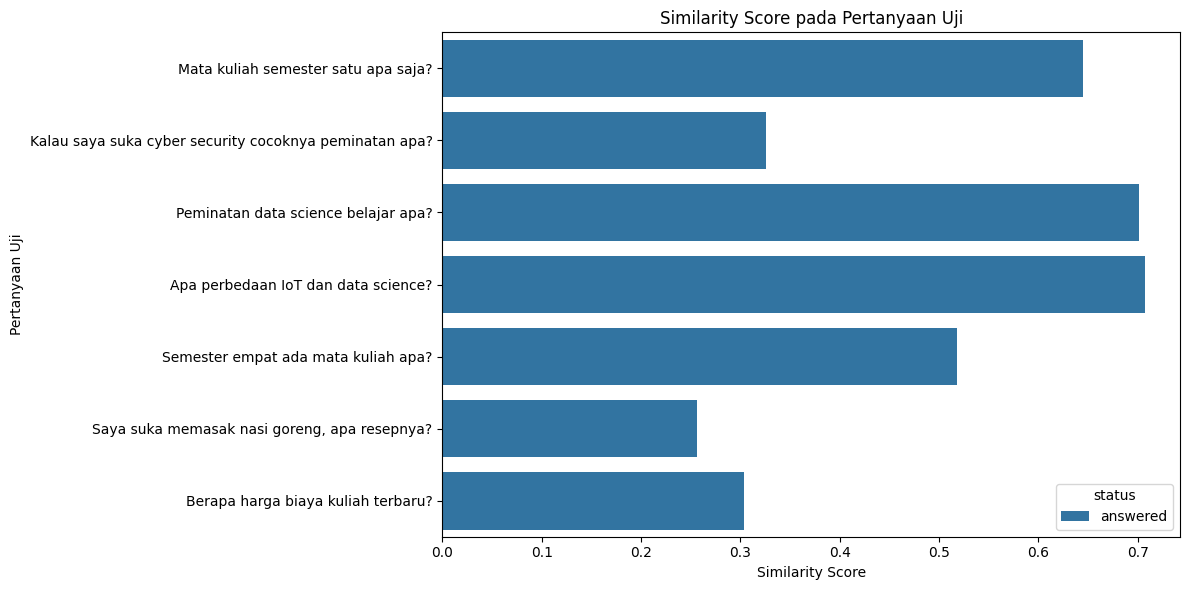

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(data=eval_result, x='similarity_score', y='test_question', hue='status')
plt.title('Similarity Score pada Pertanyaan Uji')
plt.xlabel('Similarity Score')
plt.ylabel('Pertanyaan Uji')
plt.tight_layout()
plt.show()

## 7. Kesimpulan

Prototype chatbot berhasil dibuat menggunakan pendekatan FAQ-based chatbot dengan TF-IDF dan Cosine Similarity. Sistem mampu menjawab pertanyaan yang sesuai dengan dataset FAQ dan memberikan fallback response untuk pertanyaan di luar konteks.